# 05 — Deep Learning with Temporal Convolutional Network (TCN)

Three tasks matching our classical ML methodology:
1. **Owner authentication** (binary: owner vs non-owner) — trained on normal session 1, tested on normal session 2
2. **Person identification** (4-class) — same split as classical ML
3. **Cross-context robustness** — same owner-auth model tested on crowded session 2 without retraining

In [14]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

ROOT = Path('.').resolve()
WIND = ROOT / 'windowed_data'
RES = ROOT / 'results'
FIG = ROOT / 'figures'
RES.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [15]:
X_train = np.load(WIND / 'X_train.npy')
X_test = np.load(WIND / 'X_test.npy')
meta_train = pd.read_csv(WIND / 'meta_train.csv')
meta_test = pd.read_csv(WIND / 'meta_test.csv')

print('Full dataset shapes:')
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"  Train contexts: {meta_train['context'].value_counts().to_dict()}")
print(f"  Test contexts: {meta_test['context'].value_counts().to_dict()}")

Full dataset shapes:
  X_train: (2498, 200, 6), X_test: (1770, 200, 6)
  Train contexts: {'normal': 1432, 'crowded': 1066}
  Test contexts: {'crowded': 1054, 'normal': 716}


In [16]:
OWNER = 'Pedro'

train_normal_idx = (meta_train['context'] == 'normal').values
test_normal_idx = (meta_test['context'] == 'normal').values
test_crowded_idx = (meta_test['context'] == 'crowded').values

y_owner_train = (meta_train['label_person'] == OWNER).astype(int).values
y_owner_test = (meta_test['label_person'] == OWNER).astype(int).values

# Task 1: Owner authentication — train on normal session 1, test on normal session 2
X_train_auth = X_train[train_normal_idx]
y_train_auth = y_owner_train[train_normal_idx]
X_test_auth = X_test[test_normal_idx]
y_test_auth = y_owner_test[test_normal_idx]

print('=== Task 1: Owner Authentication ===')
print(f'Train (normal s1): n={len(y_train_auth)}, owner={y_train_auth.sum()}, non-owner={(1-y_train_auth).sum()}')
print(f'Test  (normal s2): n={len(y_test_auth)}, owner={y_test_auth.sum()}, non-owner={(1-y_test_auth).sum()}')

# Task 2: Person identification — same normal-walking split
persons = sorted(meta_train.loc[train_normal_idx, 'label_person'].unique())
person_to_idx = {p: i for i, p in enumerate(persons)}
y_person_train = meta_train.loc[train_normal_idx, 'label_person'].map(person_to_idx).values
y_person_test = meta_test.loc[test_normal_idx, 'label_person'].map(person_to_idx).values
X_train_person = X_train[train_normal_idx]
X_test_person = X_test[test_normal_idx]

print(f'\n=== Task 2: Person Identification ({len(persons)}-class) ===')
print(f'Classes: {persons}')
print(f'Train: n={len(y_person_train)}, per class={np.bincount(y_person_train)}')
print(f'Test:  n={len(y_person_test)}, per class={np.bincount(y_person_test)}')

=== Task 1: Owner Authentication ===
Train (normal s1): n=1432, owner=358, non-owner=1074
Test  (normal s2): n=716, owner=179, non-owner=537

=== Task 2: Person Identification (4-class) ===
Classes: ['Darius', 'Jun', 'Oana', 'Pedro']
Train: n=1432, per class=[358 358 358 358]
Test:  n=716, per class=[179 179 179 179]


In [17]:
# Task 3: Cross-context robustness — same training data, tested on crowded session 2
X_test_crowded = X_test[test_crowded_idx]
y_test_crowded = y_owner_test[test_crowded_idx]

print('=== Task 3: Cross-context Robustness ===')
print(f'Train (normal s1):   n={len(y_train_auth)}, owner={y_train_auth.sum()}, non-owner={(1-y_train_auth).sum()}')
print(f'Test  (crowded s2):  n={len(y_test_crowded)}, owner={y_test_crowded.sum()}, non-owner={(1-y_test_crowded).sum()}')

=== Task 3: Cross-context Robustness ===
Train (normal s1):   n=1432, owner=358, non-owner=1074
Test  (crowded s2):  n=1054, owner=178, non-owner=876


In [18]:
class CausalConv1d(nn.Module):
    """Conv1d with causal (left-only) padding — no future information leakage."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)

    def forward(self, x):
        x = F.pad(x, (self.pad, 0))
        return self.conv(x)


class TemporalBlock(nn.Module):
    """Two causal convolutions with a residual connection (Bai et al., 2018)."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        return self.relu(out + residual)


class TCN(nn.Module):
    """Temporal Convolutional Network: stacked TemporalBlocks with exponential dilation."""
    def __init__(self, in_channels=6, num_channels=64, kernel_size=5,
                 num_levels=3, dropout=0.3, num_classes=2):
        super().__init__()
        blocks = []
        for i in range(num_levels):
            in_ch = in_channels if i == 0 else num_channels
            blocks.append(TemporalBlock(in_ch, num_channels, kernel_size,
                                        dilation=2**i, dropout=dropout))
        self.network = nn.Sequential(*blocks)
        self.fc1 = nn.Linear(num_channels, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y = self.network(x)
        y = y.mean(dim=2)
        y = self.dropout(torch.relu(self.fc1(y)))
        return self.fc2(y)


model_test = TCN()
print('TCN architecture (proper causal + residual):')
print(model_test)
print(f'\nTotal params: {sum(p.numel() for p in model_test.parameters()):,}')

TCN architecture (proper causal + residual):
TCN(
  (network): Sequential(
    (0): TemporalBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(6, 64, kernel_size=(5,), stride=(1,))
      )
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
      )
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (dropout): Dropout(p=0.3, inplace=False)
      (downsample): Conv1d(6, 64, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,), dilation=(2,))
      )
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,), dilation=(2,))
      )
 

In [19]:
def train_model(X_train, y_train, X_test, y_test, epochs=100, batch_size=32,
                lr=1e-3, num_channels=64, kernel_size=5, num_levels=3,
                dropout=0.3, val_frac=0.2, patience=15, verbose=True):
    """Train TCN with stratified validation split, class weights, and early stopping."""
    num_classes = len(np.unique(y_train))

    # Stratified train/val split — model selection uses val, NOT test
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=val_frac, stratify=y_train, random_state=42
    )

    X_tr_t = torch.from_numpy(X_tr).float().transpose(1, 2)
    y_tr_t = torch.from_numpy(y_tr).long()
    X_val_t = torch.from_numpy(X_val).float().transpose(1, 2)
    y_val_t = torch.from_numpy(y_val).long()
    X_te_t = torch.from_numpy(X_test).float().transpose(1, 2)
    y_te_t = torch.from_numpy(y_test).long()

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                              batch_size=batch_size, shuffle=True)

    # Inverse-frequency class weights
    class_counts = np.bincount(y_tr)
    weights = 1.0 / class_counts
    weights = weights / weights.sum() * num_classes
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    model = TCN(in_channels=X_train.shape[2], num_channels=num_channels,
                kernel_size=kernel_size, num_levels=num_levels,
                dropout=dropout, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
        train_loss /= len(y_tr_t)
        history['train_loss'].append(train_loss)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device))
            val_loss = criterion(val_logits, y_val_t.to(device)).item()
            val_acc = accuracy_score(y_val_t.numpy(),
                                     val_logits.argmax(dim=1).cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, "
                  f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)
    model.to(device)

    model.eval()
    with torch.no_grad():
        logits_te = model(X_te_t.to(device))
        pred_te = logits_te.argmax(dim=1).cpu().numpy()
        probs_te = torch.softmax(logits_te, dim=1).cpu().numpy()

    return pred_te, probs_te, history, model


def predict_with_model(model, X):
    X_t = torch.from_numpy(X).float().transpose(1, 2).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        pred = logits.argmax(dim=1).cpu().numpy()
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return pred, probs


print('Training function defined (with val split, class weights, early stopping).')

Training function defined (with val split, class weights, early stopping).


In [20]:
def evaluate_binary(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba[:, 1]) if y_proba is not None else np.nan,
    }


# --- Hyperparameter search for owner authentication ---
print('=== Hyperparameter Search (Owner Authentication) ===\n')
configs = [
    {'num_channels': 32, 'kernel_size': 3, 'num_levels': 3, 'dropout': 0.2},
    {'num_channels': 64, 'kernel_size': 5, 'num_levels': 3, 'dropout': 0.3},
    {'num_channels': 64, 'kernel_size': 7, 'num_levels': 4, 'dropout': 0.3},
    {'num_channels': 128, 'kernel_size': 5, 'num_levels': 3, 'dropout': 0.4},
]

hp_results = []
for i, cfg in enumerate(configs):
    label = f"ch={cfg['num_channels']}, ks={cfg['kernel_size']}, L={cfg['num_levels']}, do={cfg['dropout']}"
    print(f'Config {i+1}: {label}')
    pred, probs, hist, mdl = train_model(
        X_train_auth, y_train_auth, X_test_auth, y_test_auth,
        epochs=100, batch_size=32, lr=1e-3, verbose=False, **cfg
    )
    m = evaluate_binary(y_test_auth, pred, probs)
    m['config'] = label
    hp_results.append(m)
    print(f"  Test — Acc={m['accuracy']:.4f}, F1={m['f1']:.4f}, AUC={m['roc_auc']:.4f}")

hp_df = pd.DataFrame(hp_results)
print(f"\nBest config: {hp_df.loc[hp_df['f1'].idxmax(), 'config']}")
best_cfg = configs[hp_df['f1'].idxmax()]
print(f"Selected: {best_cfg}")

=== Hyperparameter Search (Owner Authentication) ===

Config 1: ch=32, ks=3, L=3, do=0.2
  Test — Acc=1.0000, F1=1.0000, AUC=1.0000
Config 2: ch=64, ks=5, L=3, do=0.3
  Test — Acc=1.0000, F1=1.0000, AUC=1.0000
Config 3: ch=64, ks=7, L=4, do=0.3
  Test — Acc=1.0000, F1=1.0000, AUC=1.0000
Config 4: ch=128, ks=5, L=3, do=0.4
  Test — Acc=1.0000, F1=1.0000, AUC=1.0000

Best config: ch=32, ks=3, L=3, do=0.2
Selected: {'num_channels': 32, 'kernel_size': 3, 'num_levels': 3, 'dropout': 0.2}


In [21]:
# --- Task 1: Final owner authentication model with best config ---
print('=== Task 1: Owner Authentication (best config) ===\n')
pred_te_auth, probs_te_auth, hist_auth, model_auth = train_model(
    X_train_auth, y_train_auth, X_test_auth, y_test_auth,
    epochs=150, batch_size=32, lr=1e-3, **best_cfg
)

metrics_auth = evaluate_binary(y_test_auth, pred_te_auth, probs_te_auth)
print(f"\nOwner authentication — Test:")
print(f"  Acc={metrics_auth['accuracy']:.4f}, F1={metrics_auth['f1']:.4f}, "
      f"Prec={metrics_auth['precision']:.4f}, Rec={metrics_auth['recall']:.4f}, "
      f"AUC={metrics_auth['roc_auc']:.4f}")
print(f"Baseline (RF): Acc=1.000, F1=1.000, Prec=1.000, Rec=1.000, AUC=1.000")

=== Task 1: Owner Authentication (best config) ===

  Epoch 20/150: train_loss=0.0002, val_loss=0.0000, val_acc=1.0000
  Epoch 40/150: train_loss=0.0001, val_loss=0.0000, val_acc=1.0000
  Epoch 60/150: train_loss=0.0000, val_loss=0.0000, val_acc=1.0000
  Epoch 80/150: train_loss=0.0000, val_loss=0.0000, val_acc=1.0000
  Epoch 100/150: train_loss=0.0000, val_loss=0.0000, val_acc=1.0000
  Epoch 120/150: train_loss=0.0000, val_loss=0.0000, val_acc=1.0000
  Epoch 140/150: train_loss=0.0000, val_loss=0.0000, val_acc=1.0000
  Early stopping at epoch 142

Owner authentication — Test:
  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000
Baseline (RF): Acc=1.000, F1=1.000, Prec=1.000, Rec=1.000, AUC=1.000


In [22]:
# --- Task 2: Person Identification (4-class) ---
print('=== Task 2: Person Identification ===\n')
pred_te_person, probs_te_person, hist_person, model_person = train_model(
    X_train_person, y_person_train, X_test_person, y_person_test,
    epochs=150, batch_size=32, lr=1e-3, **best_cfg
)

metrics_person = {
    'accuracy': accuracy_score(y_person_test, pred_te_person),
    'macro_f1': f1_score(y_person_test, pred_te_person, average='macro'),
}
print(f"\nPerson identification — Test:")
print(f"  Acc={metrics_person['accuracy']:.4f}, Macro F1={metrics_person['macro_f1']:.4f}")
print(f"Baseline (SVM): Acc=0.994, Macro F1=0.994")

=== Task 2: Person Identification ===

  Epoch 20/150: train_loss=0.0009, val_loss=0.0001, val_acc=1.0000
  Epoch 40/150: train_loss=0.0003, val_loss=0.0000, val_acc=1.0000
  Epoch 60/150: train_loss=0.0003, val_loss=0.0000, val_acc=1.0000
  Early stopping at epoch 60

Person identification — Test:
  Acc=1.0000, Macro F1=1.0000
Baseline (SVM): Acc=0.994, Macro F1=0.994


In [23]:
# --- Task 3: Cross-context Robustness ---
print('=== Task 3: Cross-context Robustness ===')
print('Same owner-auth model (trained on normal), tested on crowded without retraining\n')

pred_te_crowded, probs_te_crowded = predict_with_model(model_auth, X_test_crowded)

metrics_normal = metrics_auth
metrics_crowded = evaluate_binary(y_test_crowded, pred_te_crowded, probs_te_crowded)

print(f"Normal test:  Acc={metrics_normal['accuracy']:.4f}, F1={metrics_normal['f1']:.4f}, "
      f"Prec={metrics_normal['precision']:.4f}, Rec={metrics_normal['recall']:.4f}")
print(f"Crowded test: Acc={metrics_crowded['accuracy']:.4f}, F1={metrics_crowded['f1']:.4f}, "
      f"Prec={metrics_crowded['precision']:.4f}, Rec={metrics_crowded['recall']:.4f}")
print(f"\nBaseline (RF): normal=1.000/1.000, crowded=0.903/0.673")

=== Task 3: Cross-context Robustness ===
Same owner-auth model (trained on normal), tested on crowded without retraining

Normal test:  Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000
Crowded test: Acc=0.9924, F1=0.9780, Prec=0.9570, Rec=1.0000

Baseline (RF): normal=1.000/1.000, crowded=0.903/0.673


In [24]:
# Save all results
dl_results = pd.DataFrame([
    {'task': 'Owner authentication', 'accuracy': metrics_auth['accuracy'],
     'f1': metrics_auth['f1'], 'precision': metrics_auth['precision'],
     'recall': metrics_auth['recall'], 'roc_auc': metrics_auth['roc_auc'],
     'model': 'TCN'},
    {'task': 'Person identification', 'accuracy': metrics_person['accuracy'],
     'macro_f1': metrics_person['macro_f1'], 'model': 'TCN'},
    {'task': 'Cross-context robustness', 'accuracy': metrics_normal['accuracy'],
     'f1': metrics_normal['f1'], 'precision': metrics_normal['precision'],
     'recall': metrics_normal['recall'], 'roc_auc': metrics_normal['roc_auc'],
     'model': 'TCN', 'subset': 'normal_test'},
    {'task': 'Cross-context robustness', 'accuracy': metrics_crowded['accuracy'],
     'f1': metrics_crowded['f1'], 'precision': metrics_crowded['precision'],
     'recall': metrics_crowded['recall'], 'roc_auc': metrics_crowded['roc_auc'],
     'model': 'TCN', 'subset': 'crowded_test'},
])
dl_results.to_csv(RES / 'deeplearning_results.csv', index=False)

print('=== Deep Learning vs Classical ML ===')
print(f"\n{'Task':<35} {'Model':<8} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'AUC':>6}")
print('-' * 80)
print(f"{'Owner authentication':<35} {'RF':<8} {'1.000':>6} {'1.000':>6} {'1.000':>6} {'1.000':>6} {'1.000':>6}")
print(f"{'Owner authentication':<35} {'TCN':<8} {metrics_auth['accuracy']:>6.3f} {metrics_auth['f1']:>6.3f} {metrics_auth['precision']:>6.3f} {metrics_auth['recall']:>6.3f} {metrics_auth['roc_auc']:>6.3f}")
print(f"{'Person identification':<35} {'SVM':<8} {'0.994':>6} {'0.994':>6}")
print(f"{'Person identification':<35} {'TCN':<8} {metrics_person['accuracy']:>6.3f} {metrics_person['macro_f1']:>6.3f}")
print(f"{'Cross-context (normal test)':<35} {'RF':<8} {'1.000':>6} {'1.000':>6} {'1.000':>6} {'1.000':>6}")
print(f"{'Cross-context (normal test)':<35} {'TCN':<8} {metrics_normal['accuracy']:>6.3f} {metrics_normal['f1']:>6.3f} {metrics_normal['precision']:>6.3f} {metrics_normal['recall']:>6.3f}")
print(f"{'Cross-context (crowded test)':<35} {'RF':<8} {'0.903':>6} {'0.673':>6} {'0.784':>6} {'0.590':>6}")
print(f"{'Cross-context (crowded test)':<35} {'TCN':<8} {metrics_crowded['accuracy']:>6.3f} {metrics_crowded['f1']:>6.3f} {metrics_crowded['precision']:>6.3f} {metrics_crowded['recall']:>6.3f}")

=== Deep Learning vs Classical ML ===

Task                                Model       Acc     F1   Prec    Rec    AUC
--------------------------------------------------------------------------------
Owner authentication                RF        1.000  1.000  1.000  1.000  1.000
Owner authentication                TCN       1.000  1.000  1.000  1.000  1.000
Person identification               SVM       0.994  0.994
Person identification               TCN       1.000  1.000
Cross-context (normal test)         RF        1.000  1.000  1.000  1.000
Cross-context (normal test)         TCN       1.000  1.000  1.000  1.000
Cross-context (crowded test)        RF        0.903  0.673  0.784  0.590
Cross-context (crowded test)        TCN       0.992  0.978  0.957  1.000


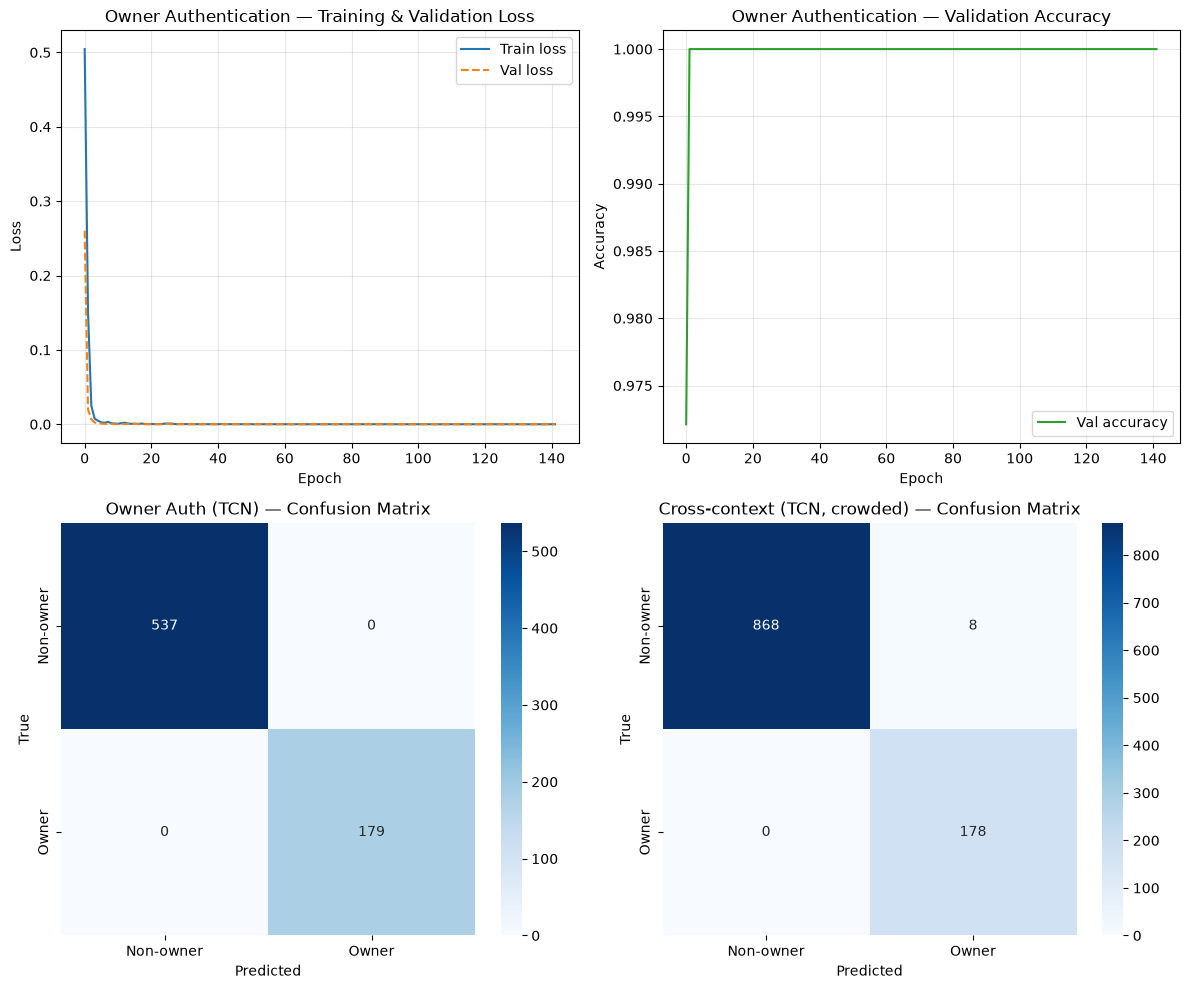

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Training curves — owner auth
axes[0, 0].plot(hist_auth['train_loss'], label='Train loss')
axes[0, 0].plot(hist_auth['val_loss'], label='Val loss', linestyle='--')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Owner Authentication — Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(hist_auth['val_acc'], label='Val accuracy', color='tab:green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Owner Authentication — Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrices
cm_auth = confusion_matrix(y_test_auth, pred_te_auth)
sns.heatmap(cm_auth, annot=True, fmt='d', ax=axes[1, 0], cmap='Blues',
            xticklabels=['Non-owner', 'Owner'], yticklabels=['Non-owner', 'Owner'])
axes[1, 0].set_title('Owner Auth (TCN) — Confusion Matrix')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_xlabel('Predicted')

cm_crowded = confusion_matrix(y_test_crowded, pred_te_crowded)
sns.heatmap(cm_crowded, annot=True, fmt='d', ax=axes[1, 1], cmap='Blues',
            xticklabels=['Non-owner', 'Owner'], yticklabels=['Non-owner', 'Owner'])
axes[1, 1].set_title('Cross-context (TCN, crowded) — Confusion Matrix')
axes[1, 1].set_ylabel('True')
axes[1, 1].set_xlabel('Predicted')

fig.tight_layout()
fig.savefig(FIG / 'fig15_tcn_results.png', dpi=150)
plt.show()

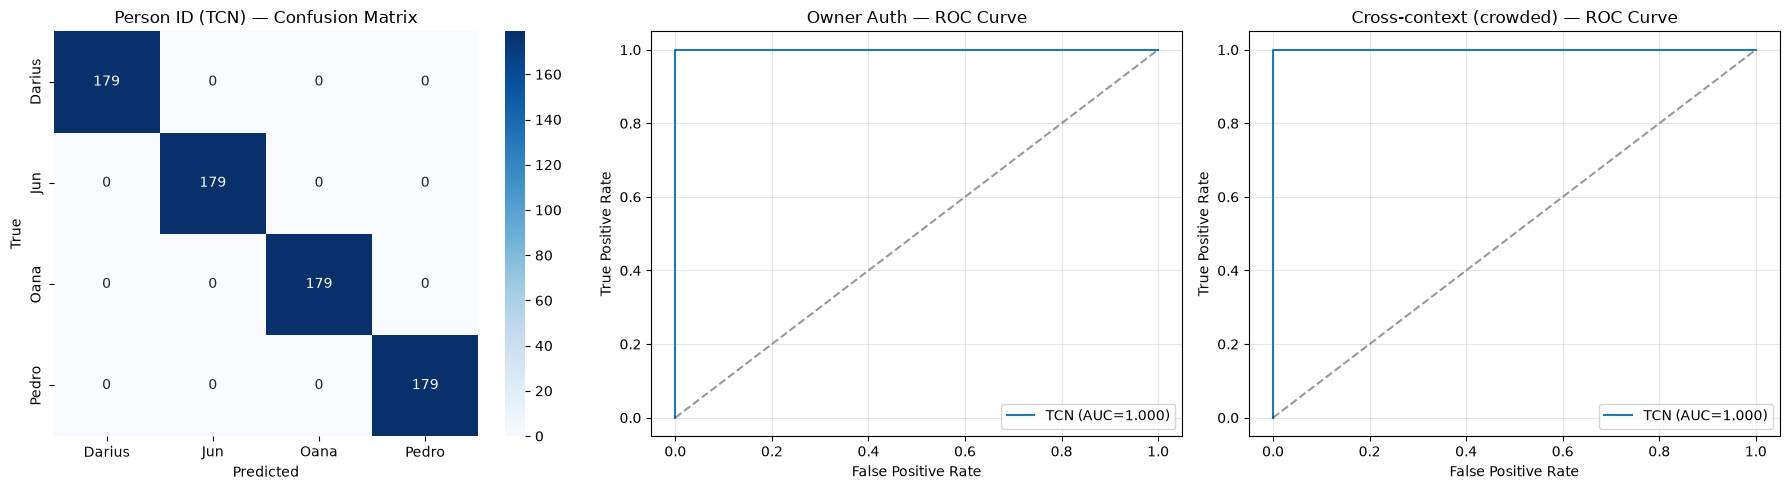

In [26]:
# Person identification confusion matrix + ROC curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Person ID confusion matrix
cm_person = confusion_matrix(y_person_test, pred_te_person)
sns.heatmap(cm_person, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=persons, yticklabels=persons)
axes[0].set_title('Person ID (TCN) — Confusion Matrix')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Owner auth ROC
fpr_auth, tpr_auth, _ = roc_curve(y_test_auth, probs_te_auth[:, 1])
axes[1].plot(fpr_auth, tpr_auth, label=f'TCN (AUC={metrics_auth["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Owner Auth — ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cross-context ROC
fpr_crowded, tpr_crowded, _ = roc_curve(y_test_crowded, probs_te_crowded[:, 1])
axes[2].plot(fpr_crowded, tpr_crowded, label=f'TCN (AUC={metrics_crowded["roc_auc"]:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Cross-context (crowded) — ROC Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG / 'fig16_tcn_roc.png', dpi=150)
plt.show()

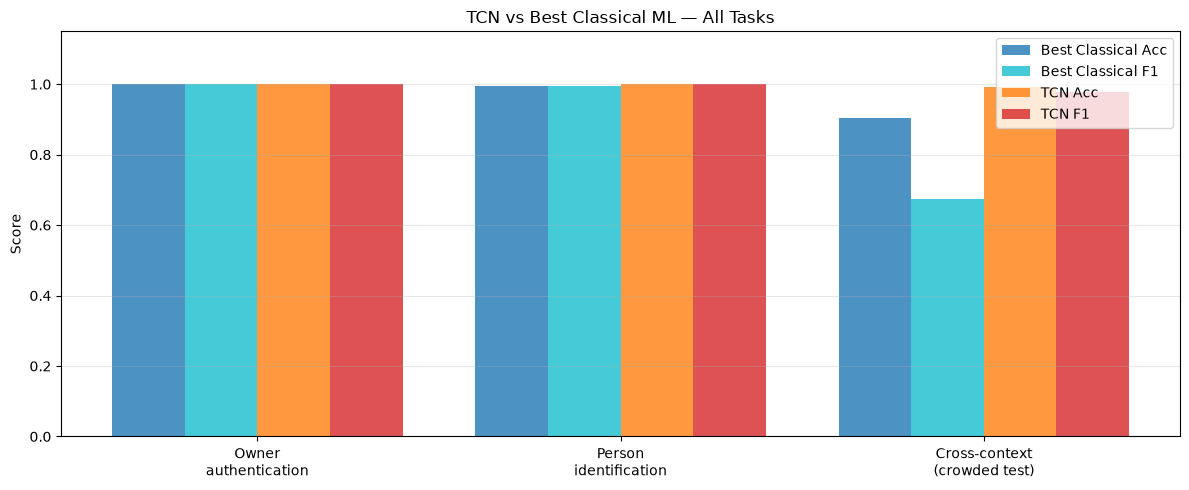

In [27]:
# TCN vs Classical ML comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))

tasks = ['Owner\nauthentication', 'Person\nidentification', 'Cross-context\n(crowded test)']
classical_accs = [1.000, 0.994, 0.903]
classical_f1s = [1.000, 0.994, 0.673]
dl_accs = [metrics_auth['accuracy'], metrics_person['accuracy'], metrics_crowded['accuracy']]
dl_f1s = [metrics_auth['f1'], metrics_person['macro_f1'], metrics_crowded['f1']]

x = np.arange(len(tasks))
width = 0.2

ax.bar(x - 1.5*width, classical_accs, width, label='Best Classical Acc', alpha=0.8, color='tab:blue')
ax.bar(x - 0.5*width, classical_f1s, width, label='Best Classical F1', alpha=0.8, color='tab:cyan')
ax.bar(x + 0.5*width, dl_accs, width, label='TCN Acc', alpha=0.8, color='tab:orange')
ax.bar(x + 1.5*width, dl_f1s, width, label='TCN F1', alpha=0.8, color='tab:red')

ax.set_ylabel('Score')
ax.set_title('TCN vs Best Classical ML — All Tasks')
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.set_ylim([0, 1.15])
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(FIG / 'fig17_tcn_vs_classical.png', dpi=150)
plt.show()

In [28]:
print('\n' + '='*60)
print('TEMPORAL CONVOLUTIONAL NETWORK (TCN) RESULTS SUMMARY')
print('='*60)

print(f"\nArchitecture: Causal dilated convolutions with residual connections (Bai et al., 2018)")
print(f"Best hyperparameters: {best_cfg}")

print(f"\nTask 1: Owner Authentication")
print(f"  TCN:      Acc={metrics_auth['accuracy']:.4f}, F1={metrics_auth['f1']:.4f}, "
      f"Prec={metrics_auth['precision']:.4f}, Rec={metrics_auth['recall']:.4f}, "
      f"AUC={metrics_auth['roc_auc']:.4f}")
print(f"  Best ML:  Acc=1.0000, F1=1.0000 (RF)")

print(f"\nTask 2: Person Identification")
print(f"  TCN:      Acc={metrics_person['accuracy']:.4f}, Macro F1={metrics_person['macro_f1']:.4f}")
print(f"  Best ML:  Acc=0.9944, Macro F1=0.9944 (SVM)")

print(f"\nTask 3: Cross-context Robustness")
print(f"  Normal test:")
print(f"    TCN:    Acc={metrics_normal['accuracy']:.4f}, F1={metrics_normal['f1']:.4f}")
print(f"    RF:     Acc=1.0000, F1=1.0000")
print(f"  Crowded test:")
print(f"    TCN:    Acc={metrics_crowded['accuracy']:.4f}, F1={metrics_crowded['f1']:.4f}, "
      f"Prec={metrics_crowded['precision']:.4f}, Rec={metrics_crowded['recall']:.4f}")
print(f"    RF:     Acc=0.9032, F1=0.6731, Prec=0.7836, Rec=0.5899")

print(f"\nAll results saved to {RES}/")


TEMPORAL CONVOLUTIONAL NETWORK (TCN) RESULTS SUMMARY

Architecture: Causal dilated convolutions with residual connections (Bai et al., 2018)
Best hyperparameters: {'num_channels': 32, 'kernel_size': 3, 'num_levels': 3, 'dropout': 0.2}

Task 1: Owner Authentication
  TCN:      Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000
  Best ML:  Acc=1.0000, F1=1.0000 (RF)

Task 2: Person Identification
  TCN:      Acc=1.0000, Macro F1=1.0000
  Best ML:  Acc=0.9944, Macro F1=0.9944 (SVM)

Task 3: Cross-context Robustness
  Normal test:
    TCN:    Acc=1.0000, F1=1.0000
    RF:     Acc=1.0000, F1=1.0000
  Crowded test:
    TCN:    Acc=0.9924, F1=0.9780, Prec=0.9570, Rec=1.0000
    RF:     Acc=0.9032, F1=0.6731, Prec=0.7836, Rec=0.5899

All results saved to C:\Users\Jun\Documents\ML4QS\Experiment\results/
